<a href="https://colab.research.google.com/github/KDY-RiskManager/risk-management-portfolio/blob/main/03-operational-risk/operational_risk_EVT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fontpath = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(fontpath)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

한글 폰트 설정.

In [2]:
np.random.seed(42)

n_years = 10
annual_freq_lambda = 25

loss_records = []
for year in range(2016, 2016 + n_years):
    n_events = np.random.poisson(annual_freq_lambda)
    severities = np.random.lognormal(mean=8.5, sigma=1.8, size=n_events)
    for amount in severities:
        loss_records.append({'year': year, 'loss_amount': amount})

df_loss = pd.DataFrame(loss_records)
print(f"총 손실 건수: {len(df_loss)}건")
df_loss.head()

총 손실 건수: 256건


,year,loss_amount
0,2016,15769.600845
1,2016,76225.683717
2,2016,3224.470164
3,2016,3224.565455
4,2016,84337.599769


지난번 LDA 분석과 완전히 동일한 시드(42)와 파라미터를 써서, 그때 만들었던 손실 데이터를 그대로 재현. 이를 통해 "그때 로그정규분포로 가정했던 게 맞았는지"를 같은 데이터로 검증할 수 있음.

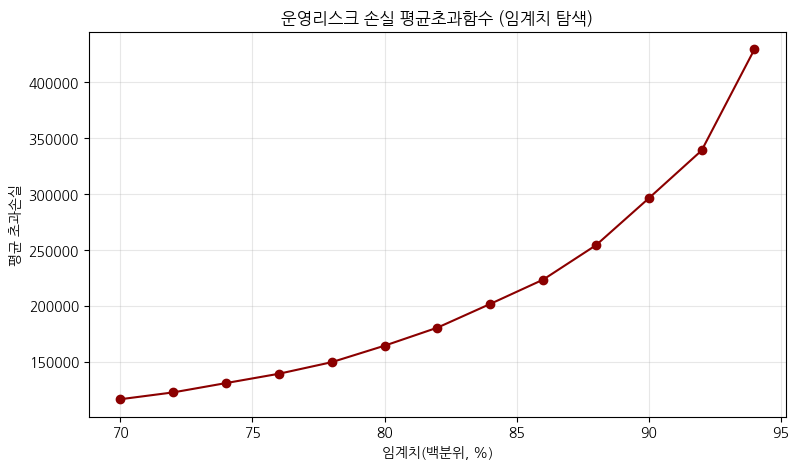

In [3]:
loss_amounts = df_loss['loss_amount'].values
percentile_grid = np.arange(70, 96, 2)
mean_excess_op = []

for p in percentile_grid:
    u = np.percentile(loss_amounts, p)
    exc = loss_amounts[loss_amounts > u] - u
    mean_excess_op.append(exc.mean())

plt.figure(figsize=(9,5))
plt.plot(percentile_grid, mean_excess_op, marker='o', color='darkred')
plt.xlabel('임계치(백분위, %)')
plt.ylabel('평균 초과손실')
plt.title('운영리스크 손실 평균초과함수 (임계치 탐색)')
plt.grid(alpha=0.3)
plt.show()

약 250건 정도의 손실 데이터가 있는데, 이 중 어느 지점부터를 "극단 손실"로 볼지 탐색하는 그래프. 그래프가 우상향할수록 fat tail 신호이고, 평평해지는 구간이 있다면 그 부근이 안정적인 임계치 후보.

In [4]:
from scipy.stats import genpareto

threshold_op = np.percentile(loss_amounts, 90)
exceedances_op = loss_amounts[loss_amounts > threshold_op] - threshold_op

print(f"임계치: {threshold_op:,.0f}")
print(f"극단치 개수: {len(exceedances_op)}개 / 전체 {len(loss_amounts)}개")

shape_op, loc_op, scale_op = genpareto.fit(exceedances_op, floc=0)
print(f"GPD 추정 모수: shape(xi)={shape_op:.4f}, scale(beta)={scale_op:.4f}")

임계치: 39,166
극단치 개수: 26개 / 전체 256개
GPD 추정 모수: shape(xi)=0.8159, scale(beta)=63967.8097


전체 손실 중 상위 10%를 극단치로 정의. 이때 GPD가 적합함. shape가 0보다 크면, 지난번 로그정규분포 가정보다 실제 꼬리가 더 두꺼울 수 있다는 신호. — 로그정규분포도 fat tail이긴 하지만, 파레토형 GPD가 더 극단적인 꼬리를 표현할 수 있음.

In [5]:
from scipy.stats import lognorm

n = len(loss_amounts)
n_u = len(exceedances_op)

def evt_quantile(p, threshold, shape, scale, n, n_u):
    # p: 예를 들어 0.999면 99.9% 분위수
    return threshold + (scale/shape) * (((n/n_u) * (1-p))**(-shape) - 1)

# 기존 로그정규 가정 기준 분위수
log_losses = np.log(loss_amounts)
mu_hat, sigma_hat = log_losses.mean(), log_losses.std()

for p in [0.95, 0.99, 0.999]:
    q_evt = evt_quantile(p, threshold_op, shape_op, scale_op, n, n_u)
    q_lognorm = lognorm.ppf(p, s=sigma_hat, scale=np.exp(mu_hat))
    print(f"{p*100}% 분위수  |  EVT(GPD): {q_evt:,.0f}  |  로그정규 가정: {q_lognorm:,.0f}")

95.0% 분위수  |  EVT(GPD): 100,539  |  로그정규 가정: 88,544
99.0% 분위수  |  EVT(GPD): 480,434  |  로그정규 가정: 302,413
99.9% 분위수  |  EVT(GPD): 3,362,048  |  로그정규 가정: 1,198,209


같은 손실 데이터에 대해, EVT로 추정한 극단 손실액과 지난번에 썼던 로그정규분포 가정으로 계산한 값을 나란히 비교. 두 값이 크게 다르다면, "로그정규 가정 하나로는 부족했다"는 걸 보여주는 중요한 근거가 됨.

    임계치_백분위  극단치_개수  shape(xi)
0        75      64   1.007912
1        77      59   1.060687
2        79      54   1.237686
3        81      49   1.173223
4        83      44   1.034747
5        85      39   0.964680
6        87      34   0.942933
7        89      29   0.862719
8        91      23   0.939292
9        93      18   1.171040
10       95      13   0.941845


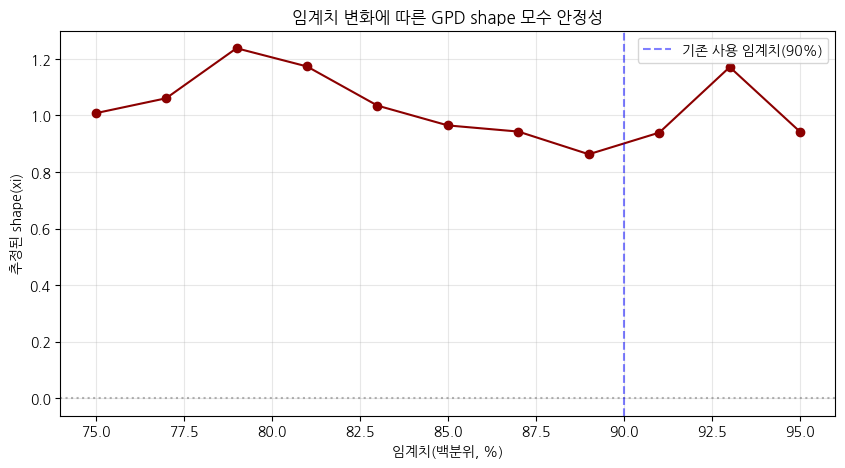

In [6]:
percentile_range_op = np.arange(75, 96, 2)
shapes_op = []
n_exc_op = []

for p in percentile_range_op:
    u = np.percentile(loss_amounts, p)
    exc = loss_amounts[loss_amounts > u] - u
    if len(exc) > 10:
        xi, _, beta = genpareto.fit(exc, floc=0)
        shapes_op.append(xi)
        n_exc_op.append(len(exc))
    else:
        shapes_op.append(np.nan)
        n_exc_op.append(len(exc))

shape_op_df = pd.DataFrame({'임계치_백분위': percentile_range_op, '극단치_개수': n_exc_op, 'shape(xi)': shapes_op})
print(shape_op_df)

plt.figure(figsize=(10,5))
plt.plot(percentile_range_op, shapes_op, marker='o', color='darkred')
plt.axhline(0, color='gray', linestyle=':', alpha=0.6)
plt.axvline(90, color='blue', linestyle='--', alpha=0.5, label='기존 사용 임계치(90%)')
plt.xlabel('임계치(백분위, %)')
plt.ylabel('추정된 shape(xi)')
plt.title('임계치 변화에 따른 GPD shape 모수 안정성')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

시장·신용리스크 때와 똑같은 검증. shape 값이 여러 임계치에서 비슷하게 나오는 안정 구간이 있는지 확인.

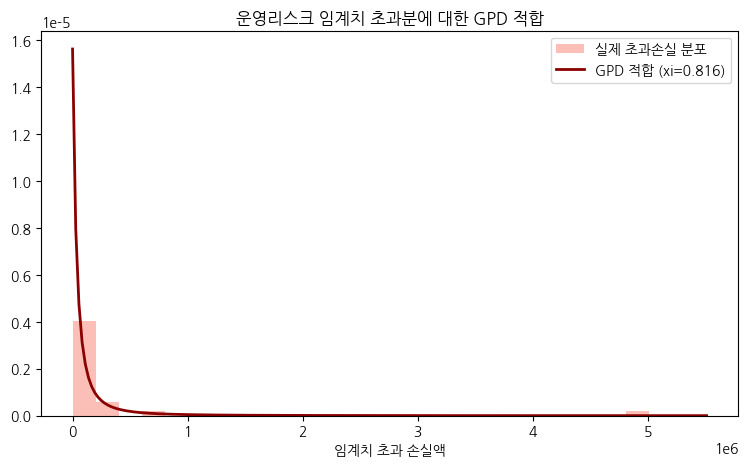

In [7]:
x = np.linspace(0, exceedances_op.max()*1.1, 200)
pdf_fitted_op = genpareto.pdf(x, shape_op, loc=0, scale=scale_op)

plt.figure(figsize=(9,5))
plt.hist(exceedances_op, bins=25, density=True, alpha=0.5, color='salmon', label='실제 초과손실 분포')
plt.plot(x, pdf_fitted_op, color='darkred', linewidth=2, label=f'GPD 적합 (xi={shape_op:.3f})')
plt.title('운영리스크 임계치 초과분에 대한 GPD 적합')
plt.xlabel('임계치 초과 손실액')
plt.legend()
plt.show()

꼬리 분포 시각화.

In [8]:
p_tail = len(exceedances_op) / len(loss_amounts)  # 전체 손실 중 극단치 비율
body_losses = loss_amounts[loss_amounts <= threshold_op]  # 임계치 이하 '평범한' 손실

def sample_severity_spliced(size):
    draws = np.empty(size)
    is_tail = np.random.rand(size) < p_tail
    n_tail = is_tail.sum()
    n_body = size - n_tail
    if n_body > 0:
        draws[~is_tail] = np.random.choice(body_losses, size=n_body, replace=True)  # 몸통: 실제 데이터에서 재추출
    if n_tail > 0:
        draws[is_tail] = threshold_op + genpareto.rvs(shape_op, scale=scale_op, size=n_tail)  # 꼬리: GPD로 생성
    return draws

print(f"극단치 비율(p_tail): {p_tail:.3f}")
print(f"몸통 데이터 개수: {len(body_losses)}개")

극단치 비율(p_tail): 0.102
몸통 데이터 개수: 230개


하나의 손실 사건이 발생했을 때, 확률 p_tail만큼은 "극단 손실(GPD에서 생성)"로, 나머지는 "평범한 손실(실제 데이터에서 재추출)"로 시뮬레이션하는 함수.

In [9]:
n_simulations = 10000
annual_total_losses_spliced = []

for _ in range(n_simulations):
    n_events_sim = np.random.poisson(annual_freq_lambda)
    if n_events_sim > 0:
        severities_sim = sample_severity_spliced(n_events_sim)
        annual_total_losses_spliced.append(severities_sim.sum())
    else:
        annual_total_losses_spliced.append(0)

annual_total_losses_spliced = np.array(annual_total_losses_spliced)
capital_99_9_spliced = np.percentile(annual_total_losses_spliced, 99.9)

print(f"[GPD 스플라이싱 기반] 99.9% 신뢰수준 연간 손실(자본): {capital_99_9_spliced:,.0f}")

[GPD 스플라이싱 기반] 99.9% 신뢰수준 연간 손실(자본): 50,197,965


지난번 로그정규 가정 몬테카를로와 똑같은 구조지만, 손실심도를 뽑는 방식만 스플라이싱으로 변경. 빈도(포아송, lambda=25)는 동일하게 유지.

                      자기자본
BIA(총이익 15%)     1,285,000
LDA(로그정규 가정)     4,861,821
LDA(GPD 스플라이싱)  50,197,965


/tmp/ipykernel_1410/705359663.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(comparison_capital.applymap(lambda x: f"{x:,.0f}"))


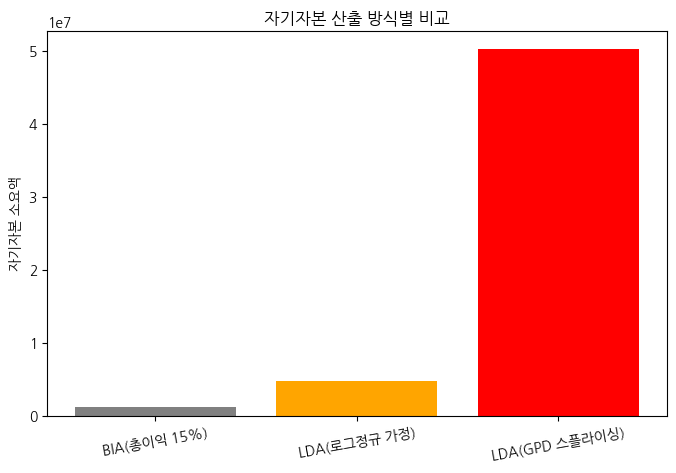

In [10]:
bia_capital_ref = 1_285_000
capital_99_9_lognormal_ref = 4_861_821

comparison_capital = pd.DataFrame({
    '자기자본': [bia_capital_ref, capital_99_9_lognormal_ref, capital_99_9_spliced]
}, index=['BIA(총이익 15%)', 'LDA(로그정규 가정)', 'LDA(GPD 스플라이싱)'])

print(comparison_capital.applymap(lambda x: f"{x:,.0f}"))

plt.figure(figsize=(8,5))
plt.bar(comparison_capital.index, comparison_capital['자기자본'], color=['gray', 'orange', 'red'])
plt.title('자기자본 산출 방식별 비교')
plt.ylabel('자기자본 소요액')
plt.xticks(rotation=10)
plt.show()

BIA, 기존 로그정규 가정 LDA, 이번에 새로 만든 GPD 스플라이싱 LDA — 세 가지를 나란히 비교.

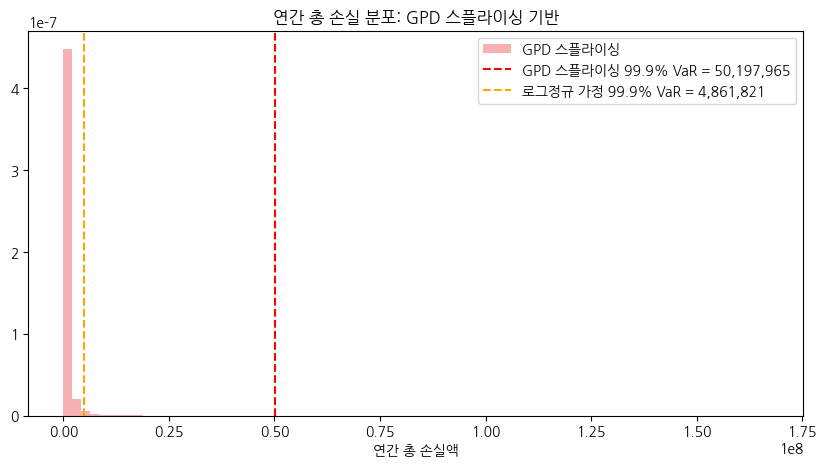

In [11]:
plt.figure(figsize=(10,5))
plt.hist(annual_total_losses_spliced, bins=80, color='lightcoral', alpha=0.6, label='GPD 스플라이싱', density=True)
plt.axvline(capital_99_9_spliced, color='red', linestyle='--', label=f'GPD 스플라이싱 99.9% VaR = {capital_99_9_spliced:,.0f}')
plt.axvline(capital_99_9_lognormal_ref, color='orange', linestyle='--', label=f'로그정규 가정 99.9% VaR = {capital_99_9_lognormal_ref:,.0f}')
plt.title('연간 총 손실 분포: GPD 스플라이싱 기반')
plt.xlabel('연간 총 손실액')
plt.legend()
plt.show()

분포 자체 시각화 비교.

In [12]:
results_by_seed = []

for trial_seed in [1, 7, 42, 100, 999]:
    np.random.seed(trial_seed)
    annual_losses_trial = []

    for _ in range(n_simulations):
        n_events_sim = np.random.poisson(annual_freq_lambda)
        if n_events_sim > 0:
            severities_sim = sample_severity_spliced(n_events_sim)
            annual_losses_trial.append(severities_sim.sum())
        else:
            annual_losses_trial.append(0)

    annual_losses_trial = np.array(annual_losses_trial)
    var_99_9_trial = np.percentile(annual_losses_trial, 99.9)
    results_by_seed.append({'seed': trial_seed, '99.9% VaR': var_99_9_trial})

results_df = pd.DataFrame(results_by_seed)
print(results_df)
print(f"\n5회 결과의 평균: {results_df['99.9% VaR'].mean():,.0f}")
print(f"5회 결과의 표준편차: {results_df['99.9% VaR'].std():,.0f}")
print(f"최솟값: {results_df['99.9% VaR'].min():,.0f} / 최댓값: {results_df['99.9% VaR'].max():,.0f}")

   seed     99.9% VaR
0     1  3.759990e+07
1     7  4.355107e+07
2    42  5.019797e+07
3   100  3.137393e+07
4   999  5.046835e+07

5회 결과의 평균: 42,638,244
5회 결과의 표준편차: 8,239,582
최솟값: 31,373,935 / 최댓값: 50,468,354


시드마다 완전히 다른 난수가 생성되니, 매번 다른 10,000개의 가상 연도가 생성됨. 만약 5번의 결과가 서로 비슷하게 나온다면 안정적인 추정이고, 크게 들쭉날쭉하다면 불안정하다는 게 통계적으로 증명.

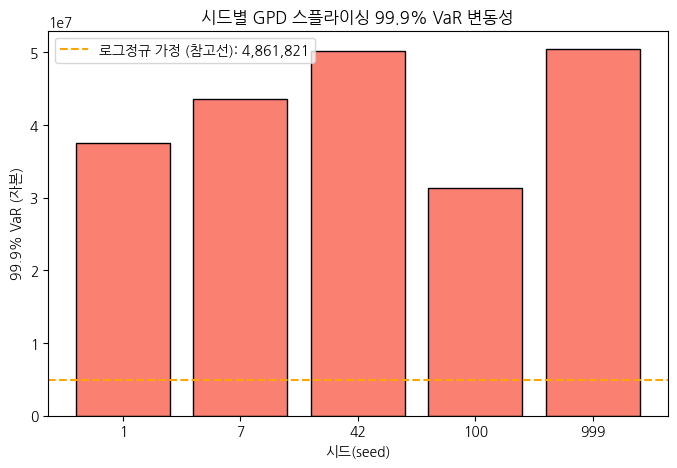

In [13]:
plt.figure(figsize=(8,5))
plt.bar(results_df['seed'].astype(str), results_df['99.9% VaR'], color='salmon', edgecolor='black')
plt.axhline(capital_99_9_lognormal_ref, color='orange', linestyle='--', label=f'로그정규 가정 (참고선): {capital_99_9_lognormal_ref:,.0f}')
plt.xlabel('시드(seed)')
plt.ylabel('99.9% VaR (자본)')
plt.title('시드별 GPD 스플라이싱 99.9% VaR 변동성')
plt.legend()
plt.show()